In [18]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Libraries for scaling numerical features
from sklearn.preprocessing import StandardScaler

# to perform k-means clustering
from sklearn.cluster import KMeans

# to perform silhouette analysis
from sklearn.metrics import silhouette_score

# to perform t-SNE
from sklearn.manifold import TSNE

# to define a common seed value to be used throughout
RS=0

# to suppress unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

In [19]:
# uncomment and run the following line if using Google Colab
# from google.colab import drive
# Write your code here to read the data
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
# loading data into a pandas dataframe
nutrient_data = pd.read_csv("/content/drive/My Drive/Nutrient_Composition_Dataset.csv")

In [21]:
## Make copy in data
data = nutrient_data.copy()

In [8]:
data.head()

,S.No,Protein,Fat,vitaminC,Fibre,Product
0,1,0.452369,1.170926,1.079271,1.702960,"Amaranth leaves, cooked, boiled, drained, with..."
1,2,2.321087,0.706856,0.350088,0.658249,Bacon and beef sticks
2,3,0.884554,1.186571,2.428544,1.984562,"Apples, frozen, unsweetened, unheated (Include..."
3,4,0.715501,0.577599,0.270925,0.369266,"Alcoholic beverage, beer, light, BUD LIGHT"
4,5,0.132610,0.544521,0.116884,0.557309,"Alcoholic beverage, daiquiri, canned"


In [9]:
data.tail()

,S.No,Protein,Fat,vitaminC,Fibre,Product
1741,1742,1.188371,1.963861,1.144457,1.438795,Unknown
1742,1743,2.325762,1.970995,1.352002,0.051109,Unknown
1743,1744,0.597130,0.727934,1.031587,0.255496,Unknown
1744,1745,0.748026,1.722406,1.319929,0.920391,Unknown
1745,1746,2.013799,0.576179,0.515998,1.536694,Unknown


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1746 entries, 0 to 1745
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   S.No      1746 non-null   int64  
 1   Protein   1746 non-null   float64
 2   Fat       1746 non-null   float64
 3   vitaminC  1746 non-null   float64
 4   Fibre     1746 non-null   float64
 5   Product   1746 non-null   object 
dtypes: float64(4), int64(1), object(1)
memory usage: 82.0+ KB


In [11]:
data = data.loc[:, ~data.columns.str.contains('S.No')]

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1746 entries, 0 to 1745
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Protein   1746 non-null   float64
 1   Fat       1746 non-null   float64
 2   vitaminC  1746 non-null   float64
 3   Fibre     1746 non-null   float64
 4   Product   1746 non-null   object 
dtypes: float64(4), object(1)
memory usage: 68.3+ KB


In [13]:
data.describe()

,Protein,Fat,vitaminC,Fibre
count,1746.000000,1746.000000,1746.000000,1746.000000
mean,0.922470,0.900091,0.900146,0.900830
std,0.627128,0.634617,0.623847,0.626875
min,0.000128,0.000267,0.000029,0.002579
25%,0.435853,0.394784,0.419103,0.389124
50%,0.813025,0.804687,0.796290,0.820783
75%,1.295106,1.298988,1.280870,1.295732
max,4.016890,3.979364,4.013322,3.570331


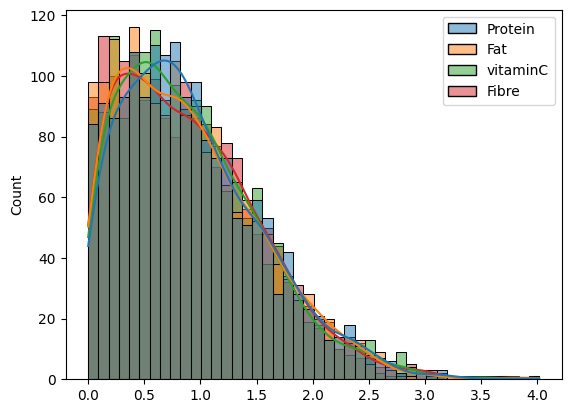

In [14]:

sns.histplot(data, kde=True)
plt.show()

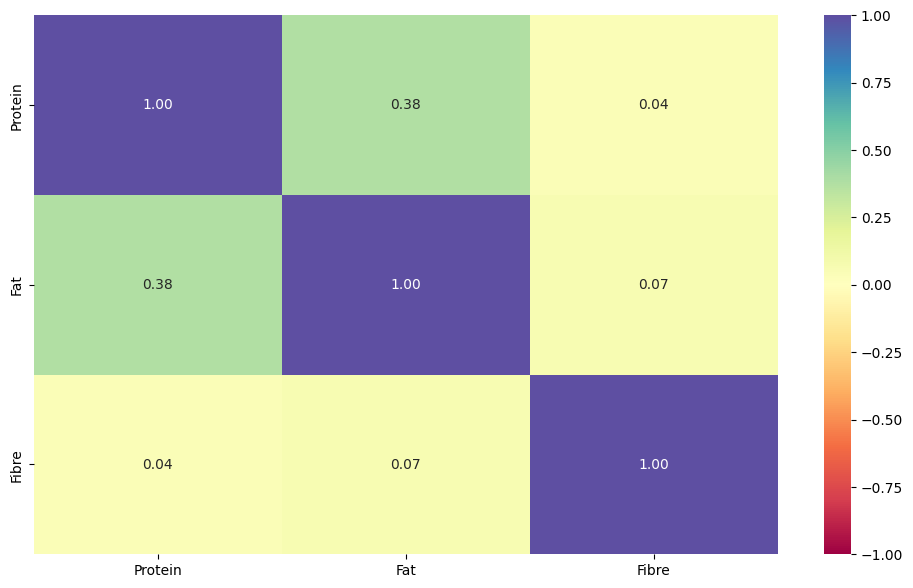

In [16]:
num_features = ['Protein', 'Fat', 'Fibre']
# defining the size of the plot
plt.figure(figsize=(12, 7))

# plotting the heatmap for correlation
sns.heatmap(data[num_features].corr(),annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral");

In [24]:
# Initialize the StandardScaler object
scaler = StandardScaler()

non_numeric_columns = data.select_dtypes(exclude='number').columns
print(non_numeric_columns)
data = data.drop(non_numeric_columns, axis=1)
# Fit the scaler to the numerical columns, transform them (i.e., execute the scaling), and create a new dataframe with scaled data
scaled_data = pd.DataFrame(scaler.fit_transform(data))

# Display the scaled data
scaled_data.head()

Index(['Product'], dtype='object')


,0,1,2,3,4
0,-1.731059,-0.749825,0.426892,0.287212,1.279936
1,-1.729075,2.230835,-0.304578,-0.881972,-0.387079
2,-1.727091,-0.060478,0.451551,2.450659,1.729280
3,-1.725107,-0.330121,-0.508314,-1.008903,-0.848201
4,-1.723123,-1.259850,-0.560451,-1.255896,-0.548145


In [26]:
scaled_data.describe()

,0,1,2,3,4,cluster
count,1746.000000,1.746000e+03,1.746000e+03,1.746000e+03,1.746000e+03,1746.000000
mean,0.000000,-2.034773e-17,-9.461695e-17,-3.052160e-18,-5.086933e-17,1.017182
std,1.000286,1.000286e+00,1.000286e+00,1.000286e+00,1.000286e+00,0.725106
min,-1.731059,-1.471161e+00,-1.418308e+00,-1.443263e+00,-1.433311e+00,0.000000
25%,-0.865530,-7.761675e-01,-7.964675e-01,-7.713125e-01,-8.165133e-01,0.000000
50%,0.000000,-1.745679e-01,-1.503757e-01,-1.665248e-01,-1.277286e-01,1.000000
75%,0.865530,5.943651e-01,6.287443e-01,6.104591e-01,6.301339e-01,2.000000
max,1.731059,4.935689e+00,4.853568e+00,4.991719e+00,4.259645e+00,2.000000


In [31]:
# Initiating the t-SNE object
# n_components=2 specifies the number of dimensions to reduce the data to
# n_jobs=-2 specifies to use all but one processor core for parallel computation, which speeds up the process
tsne = TSNE(n_components=2, n_jobs=-2, random_state=RS)
scaled_data.columns = scaled_data.columns.astype(str)
# Performing dimensionality reduction on the scaled data
# fit_transform() fits the t-SNE model to the data and transforms it into the specified number of dimensions
tsne_reduced_data = tsne.fit_transform(scaled_data)

# Creating a DataFrame from the reduced data
tsne_2d_data = pd.DataFrame(tsne_reduced_data, columns=(["Feature 1","Feature 2"])) # This DataFrame will have two columns corresponding to the two reduced dimensions

In [32]:
tsne_2d_data.head()

,Feature 1,Feature 2
0,-49.352943,-3.709474
1,48.675041,-10.896917
2,-62.213943,13.434772
3,2.082476,-37.330196
4,-6.213107,-36.468227


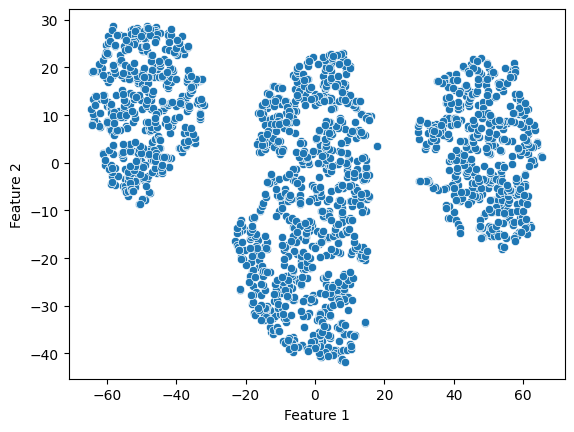

In [33]:
sns.scatterplot(data=tsne_2d_data, x="Feature 1", y="Feature 2");

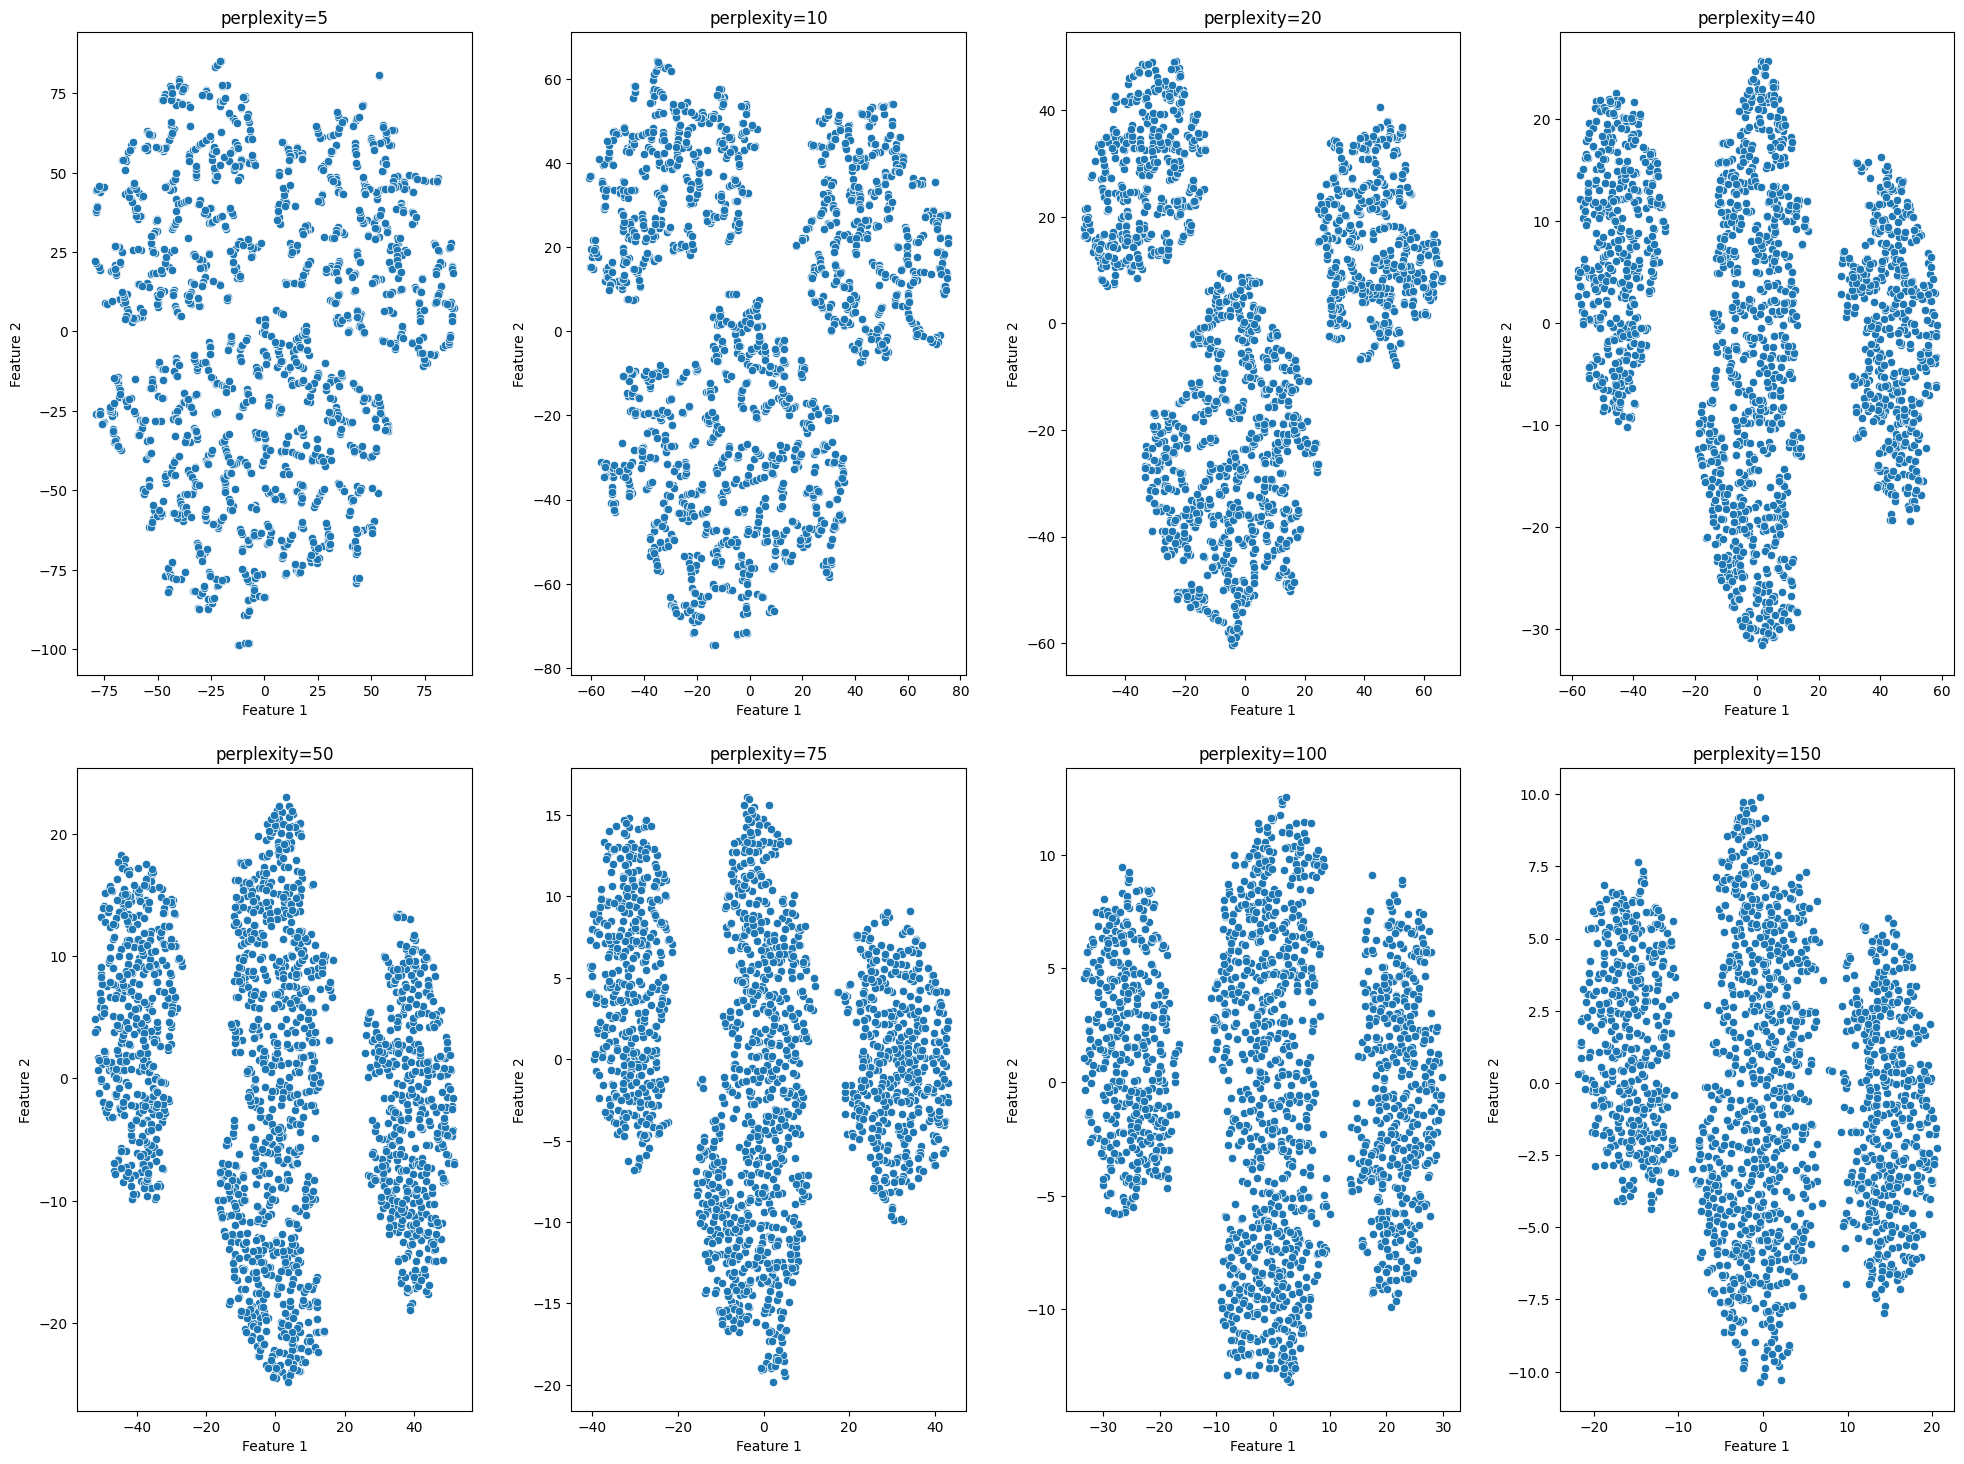

In [34]:
# Define the list of perplexity values to iterate over
perplexities = [5, 10, 20, 40, 50, 75, 100, 150]

plt.figure(figsize=(20, 15))

# Iterate over each perplexity value
for i in range(len(perplexities)):
    # Initiate TSNE with the current perplexity value
    tsne = TSNE(n_components=2, perplexity=perplexities[i], n_jobs=-2, random_state=RS)    # n_jobs specifies the nunmber of cores to use for parallel computation; -2 means use all but 1 core
    X_red = tsne.fit_transform(scaled_data)    # fit_transform() fits the TSNE model to the data and transforms it into the specified number of dimensions
    red_data_df = pd.DataFrame(data=X_red, columns=["Feature 1", "Feature 2"])    # creating a new dataframe with reduced dimensions

    # Adjust the subplot grid to 2x4
    plt.subplot(2, 4, i + 1)

    plt.title("perplexity=" + str(perplexities[i]))    # setting plot title
    sns.scatterplot(data=red_data_df, x="Feature 1", y="Feature 2")
    plt.tight_layout(pad=2)

plt.show()

In [35]:
# Initiating the t-SNE object
# n_components=2 specifies the number of dimensions to reduce the data to
# n_jobs=-2 specifies to use all but one processor core for parallel computation, which speeds up the process
tsne = TSNE(n_components=2, perplexity=50, n_jobs=-2, random_state=RS)

# Performing dimensionality reduction on the scaled data
# fit_transform() fits the t-SNE model to the data and transforms it into the specified number of dimensions
tsne_reduced_data = tsne.fit_transform(scaled_data)

# Creating a DataFrame from the reduced data
tsne_2d_data = pd.DataFrame(tsne_reduced_data, columns=(["Feature 1","Feature 2"])) # This DataFrame will have two columns corresponding to the two reduced dimensions
tsne_2d_data.head()

,Feature 1,Feature 2
0,-34.625931,-5.871249
1,36.387253,-16.309048
2,-50.026398,1.159682
3,5.581555,-21.961493
4,-0.295562,-22.228626


In [37]:
# Initiating the TSNE object and setting output dimension to 3
# n_components=3 specifies the number of dimensions to reduce the data to
# n_jobs=-2 specifies to use all but one core for parallel computation, which speeds up the process
tsne = TSNE(n_components=3, perplexity=50, n_jobs=-2, random_state=RS)

# Performing dimensionality reduction on the scaled data
# fit_transform() fits the TSNE model to the data and transforms it into the specified number of dimensions
tsne_reduced_data = tsne.fit_transform(scaled_data)

# Creating a DataFrame from the reduced data
tsne_3d_data = pd.DataFrame(tsne_reduced_data, columns=(["Feature 1","Feature 2","Feature 3"])) # This DataFrame will have three columns corresponding to the three reduced dimensions

In [38]:
tsne_3d_data.head()

,Feature 1,Feature 2,Feature 3
0,-12.557170,-2.275017,-0.904319
1,13.755265,-6.096456,-0.655974
2,-19.559605,2.039203,-1.914390
3,1.466062,-7.543746,5.450065
4,-2.412754,-6.517945,5.368422


In [39]:
# plotting a 3D scatterplot
fig = px.scatter_3d(tsne_3d_data, x='Feature 1', y='Feature 2', z='Feature 3')
fig.show()

In [40]:
# create a K-means object
n_clusters = 4
Kmeans_4 = KMeans(n_clusters=n_clusters, random_state=RS)

# fitting the model to the data
Kmeans_4.fit(scaled_data)

KMeans(n_clusters=4, random_state=0)

In [41]:
# Calculate the WCSS (Within-Cluster Sum of Squares)
wcss_k4 = Kmeans_4.inertia_

# Print the WCSS
print("WCSS for K={} is {}".format(n_clusters, wcss_k4))

WCSS for K=4 is 5258.150041615381


In [42]:
# Calculate the silhouette score
sil_score_k4 = silhouette_score(scaled_data, Kmeans_4.labels_)

# Print the silhouette score
print("Silhouette score for K={} is {}".format(n_clusters, sil_score_k4))

Silhouette score for K=4 is 0.1986915224471359


In [43]:
# Assigning cluster labels to the tsne_2d_data DataFrame
tsne_2d_data['Clusters'] = Kmeans_4.labels_
tsne_2d_data.head()

,Feature 1,Feature 2,Clusters
0,-34.625931,-5.871249,2
1,36.387253,-16.309048,0
2,-50.026398,1.159682,2
3,5.581555,-21.961493,1
4,-0.295562,-22.228626,1


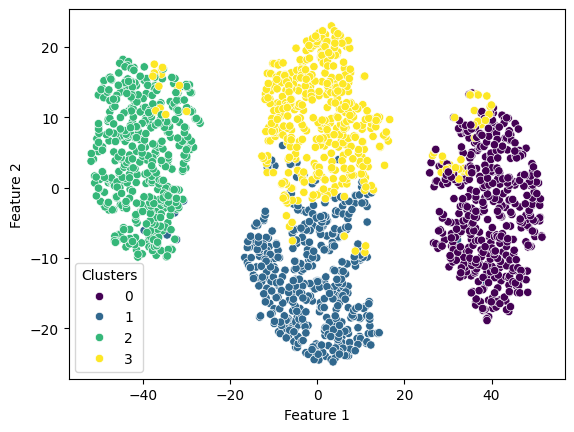

In [44]:
sns.scatterplot(tsne_2d_data, x='Feature 1', y='Feature 2', hue='Clusters', palette='viridis');

In [45]:
# Assigning cluster labels to the tsne_3d_data DataFrame
tsne_3d_data['Clusters'] = Kmeans_4.labels_
tsne_3d_data.head()

,Feature 1,Feature 2,Feature 3,Clusters
0,-12.557170,-2.275017,-0.904319,2
1,13.755265,-6.096456,-0.655974,0
2,-19.559605,2.039203,-1.914390,2
3,1.466062,-7.543746,5.450065,1
4,-2.412754,-6.517945,5.368422,1


In [46]:
fig = px.scatter_3d(tsne_3d_data, x='Feature 1', y='Feature 2', z='Feature 3', color='Clusters')
fig.show()

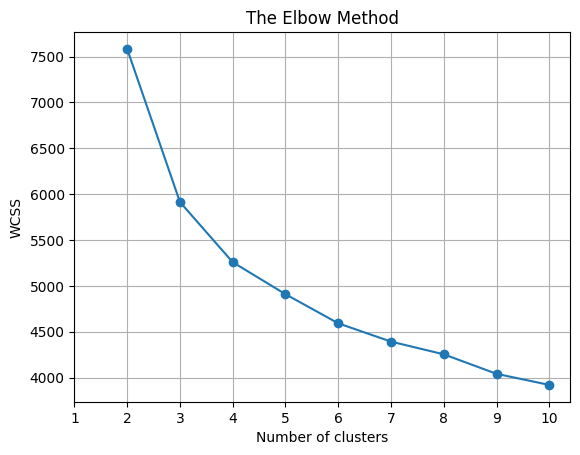

In [47]:
# calculate WCSS for a range of K values
wcss_list = []

# Iterate over a range of K values from 2 to 10
for i in range(2, 11):
    # Create a KMeans clusterer object with current K value
    clusterer = KMeans(n_clusters=i, random_state=RS)

    # Fit the clusterer to the scaled data
    clusterer.fit(scaled_data)

    # Append the inertia (WCSS) to the wcss_list
    wcss_list.append(clusterer.inertia_)

# Plot the WCSS values against the number of clusters
plt.plot(range(2, 11), wcss_list, marker='o')
plt.title('The Elbow Method')  # Set the title of the plot
plt.xlabel('Number of clusters')  # Label the x-axis
plt.ylabel('WCSS')  # Label the y-axis
plt.xticks(range(1, 11))  # Set the x-ticks from 1 to 10
plt.grid(True)  # Enable grid lines on the plot
plt.show()  # Display the plot

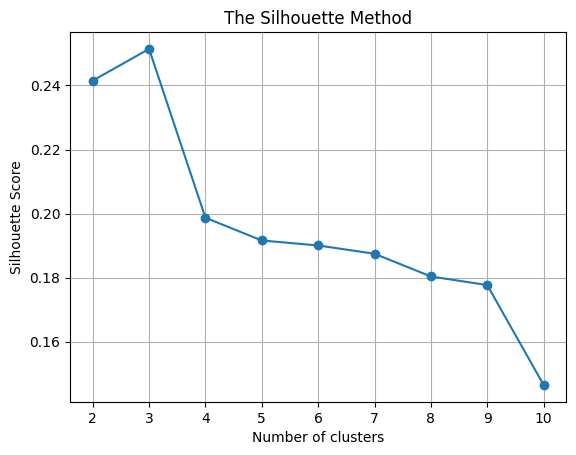

In [48]:
# calculate Silhouette Scores for a range of K values
sil_score = []

# Iterate over a range of K values from 2 to 10
for i in range(2, 11):
    # Create a KMeans clusterer object with current K value
    clusterer = KMeans(n_clusters=i, random_state=RS)

    # Fit the clusterer to the scaled data
    clusterer.fit(scaled_data)

    # Calculate Silhouette Score
    score = silhouette_score(scaled_data, clusterer.labels_)

    # Append the Silhouette Score to the sil_score list
    sil_score.append(score)

# Plot the Silhouette Scores against the number of clusters
plt.plot(range(2, 11), sil_score, marker='o')
plt.title('The Silhouette Method')  # Set the title of the plot
plt.xlabel('Number of clusters')  # Label the x-axis
plt.ylabel('Silhouette Score')  # Label the y-axis
plt.xticks(range(2, 11))  # Set the x-ticks from 2 to 10
plt.grid(True)  # Enable grid lines on the plot
plt.show()  # Display the plot

In [49]:
# create a K-means object
n_clusters = 3
Kmeans_3 = KMeans(n_clusters=n_clusters, random_state=RS)

# fitting the model to the data
Kmeans_3.fit(scaled_data)

KMeans(n_clusters=3, random_state=0)

In [50]:
# Assigning cluster labels to the tsne_2d_data DataFrame
tsne_2d_data['Clusters'] = Kmeans_3.labels_
tsne_2d_data.head()

,Feature 1,Feature 2,Clusters
0,-34.625931,-5.871249,2
1,36.387253,-16.309048,0
2,-50.026398,1.159682,2
3,5.581555,-21.961493,1
4,-0.295562,-22.228626,1


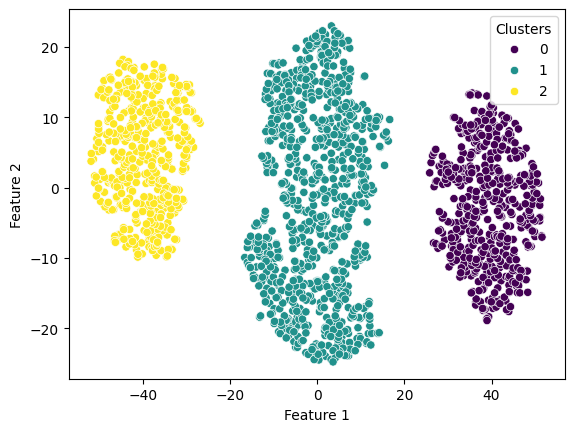

In [51]:
sns.scatterplot(tsne_2d_data, x='Feature 1', y='Feature 2', hue='Clusters', palette='viridis');

In [52]:
# Add the cluster labels back to the DataFrame
data['Clusters'] = Kmeans_4.labels_

# Display the DataFrame with original values
data.head()

,S.No,Protein,Fat,vitaminC,Fibre,Clusters
0,1,0.452369,1.170926,1.079271,1.702960,2
1,2,2.321087,0.706856,0.350088,0.658249,0
2,3,0.884554,1.186571,2.428544,1.984562,2
3,4,0.715501,0.577599,0.270925,0.369266,1
4,5,0.132610,0.544521,0.116884,0.557309,1


Clusters
3    26.002291
0    25.085911
1    24.799542
2    24.112257
Name: proportion, dtype: float64 



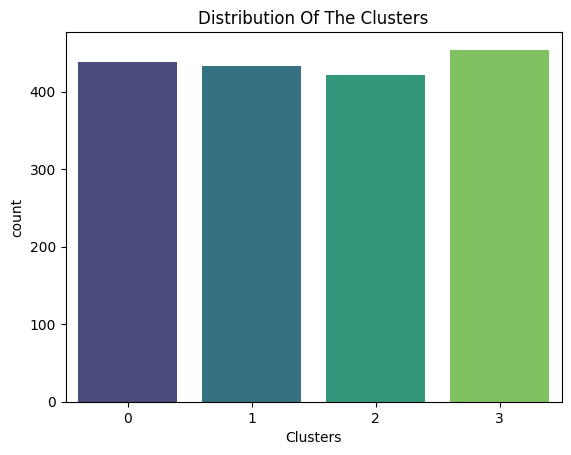

In [53]:
# checking the distribution of the categories in Clusters
print(100*data['Clusters'].value_counts(normalize=True), '\n')

# plotting the count plot for clusters
sns.countplot(data=data, x='Clusters', palette='viridis').set_title("Distribution Of The Clusters");